In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [ ]:
# Load & Explore
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

print('Shape:', df.shape)
print('Class names:', iris.target_names)
print('Feature names:', iris.feature_names)
print('Class balance:')
print(df['target'].value_counts().sort_index().rename(index=dict(enumerate(iris.target_names))))
df.head()

Shape: (150, 5)
Class names: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class balance:
target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Feature Scaling
X = df[iris.feature_names].values
y = df['target'].values

print('Mean before scaling:')
print(np.mean(X, axis=0))
print('Std before scaling:')
print(np.std(X, axis=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Mean after scaling:')
print(np.mean(X_scaled, axis=0))
print('Std after scaling:')
print(np.std(X_scaled, axis=0))

Mean before scaling:
[5.84333333 3.05733333 3.758      1.19933333]
Std before scaling:
[0.82530129 0.43441097 1.75940407 0.75969263]
Mean after scaling:
[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std after scaling:
[1. 1. 1. 1.]


In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    shuffle=True,
    random_state=42,
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 120
Testing samples: 30


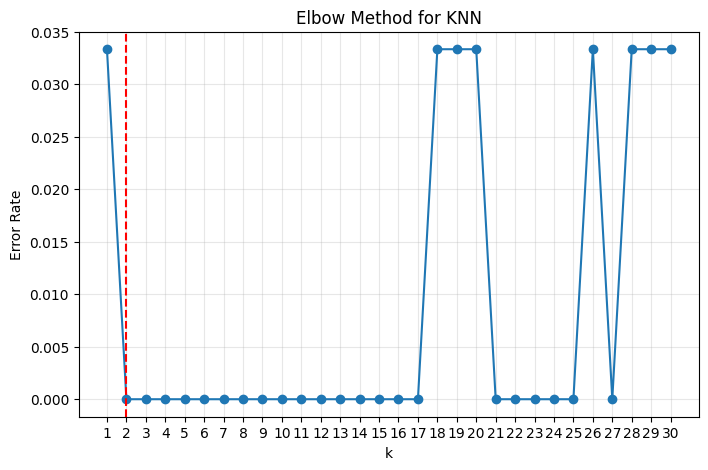

Best k: 2
Best error rate: 0.0


In [ ]:
# Elbow Method
k_values = list(range(1, 31))
error_rates = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    error_rates.append(np.mean(y_pred != y_test))

best_k_index = int(np.argmin(error_rates))
best_k = k_values[best_k_index]
best_error_rate = error_rates[best_k_index]

plt.figure(figsize=(8, 5))
plt.plot(k_values, error_rates, marker='o')
plt.axvline(best_k, color='red', linestyle='--')
plt.xlabel('k')
plt.ylabel('Error Rate')
plt.title('Elbow Method for KNN')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

print('Best k:', best_k)
print('Best error rate:', best_error_rate)

In [ ]:
# Train Final Model
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 1.0


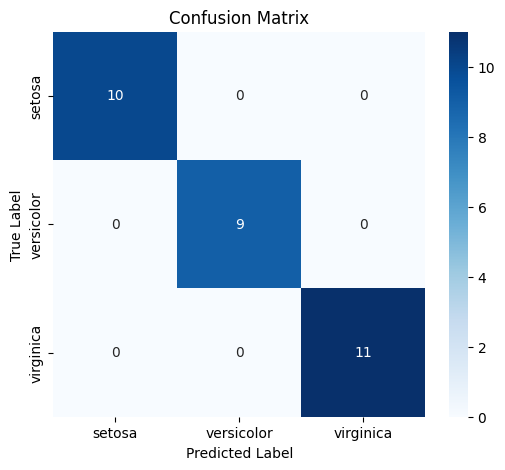

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Weighted F1 Score: 1.0


In [ ]:
# Evaluate
cm = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=iris.target_names))
print('Weighted F1 Score:', f1)